## This notebook is made to cover the machine learning part of the project

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

raw_dataframe = pd.read_csv('dropout_dataset.csv', sep=';')


#Before really splitting the data, some cleaning is done to avoid annoying errors in the future

for column in raw_dataframe.columns:
    raw_dataframe.rename(columns = {f'{column}':f'{column.rstrip().lstrip()}'})

## PCA

On this section we will analyze our dataset with unsupervised machine learning algorithms, first of all, we need to treat the data, normalize quantitative values and encode categorical ones.

Since PCA is feature driven, the column target will be dropped to prevent bias introduction in the algorithm

Original features: 36
Reduced features after PCA: 21
Variance explained by first 2 components: 36.06%


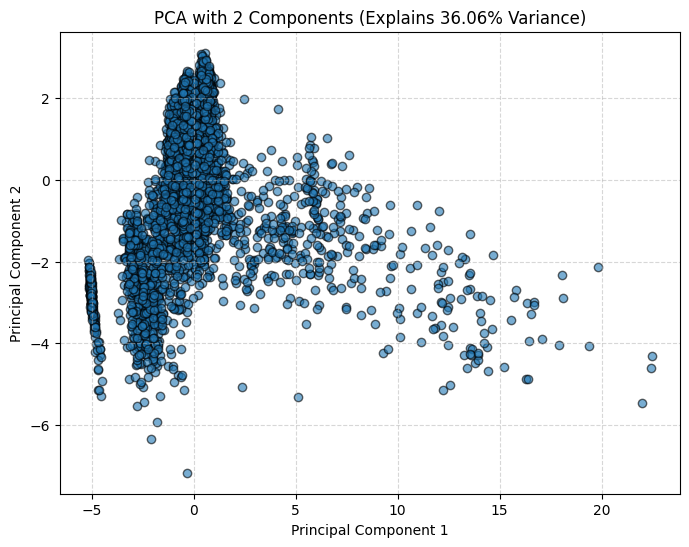

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

unsupervised_dataset = raw_dataframe.copy()

unsupervised_dataset = unsupervised_dataset.drop(columns=["Target"])

df_continuous_columns = ['Previous qualification (grade)','Admission grade', 'Unemployment rate', 
    'Inflation rate','GDP', 'Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)']

df_discrete_columns =['Age at enrollment', 'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
     'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
     'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)',
     'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
     'Curricular units 2nd sem (without evaluations)'
    ]

df_categorical_columns = ['Application mode', 'Course', 'Previous qualification', 
                          'Nacionality',"Father's occupation", "Mother's occupation"]

df_ordinal_columns = ['Marital status',  'Application order', "Mother's qualification",
                      "Father's qualification"]

# Normalize Continuous and Discrete columns
scaler = StandardScaler()
unsupervised_dataset[df_continuous_columns + df_discrete_columns] = scaler.fit_transform(unsupervised_dataset[df_continuous_columns + df_discrete_columns])

#Scale Categorical and Ordinal columns (treating them as numerical)
unsupervised_dataset[df_categorical_columns + df_ordinal_columns] = scaler.fit_transform(unsupervised_dataset[df_categorical_columns + df_ordinal_columns])

# Apply PCA (keep 95% variance)
pca_95 = PCA(n_components=0.95)
pca_2_components = PCA(n_components=2)
X_pca = pca_95.fit_transform(unsupervised_dataset)
X_pca_2 = pca_2_components.fit_transform(unsupervised_dataset)

# 🚀 Print results
print(f"Original features: {unsupervised_dataset.shape[1]}")
print(f"Reduced features after PCA: {X_pca.shape[1]}")

##Test
explained_variance = np.sum(pca_2_components.explained_variance_ratio_) * 100
print(f"Variance explained by first 2 components: {explained_variance:.2f}%")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], alpha=0.6, edgecolors='k')

# Labels and title
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"PCA with 2 Components (Explains {explained_variance:.2f}% Variance)")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

When we apply PCA to reduce the dataset from 36 components to 2 for creating a visual representation of the data, we can get a scatter plot but, since the PCA only explain 36.06 of the dataset variance, we cannot consider this a good representation of the original structure of the data

## Clustering

Since with PCA we managed to reduce the dimensions to 21 but still have a high enough dimension number that could make the output suffer from the curse of high dimensionality, different clustering methods will be applyied and compared:

**Clustering methods tested**
- K-means: an iterative, centroid-based clustering algorithm that partitions a dataset into similar groups based on the distance between their centroids.
- DBSCAN: finds core samples in regions of high density and expands clusters from them
- GMM: probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. One can think of mixture models as generalizing k-means clustering to incorporate information about the covariance structure of the data as well as the centers of the latent Gaussians. (more suitable for clusters with non conventional shapes

**Evaluation scores**
- Silhouette score: metric that evaluates how good the clustering results are in data clustering. This score measure how well each data point is fitted in its own assigned cluster. For each point, the value ranges from -1 to 1 and the total score is the average silhouette score for all points
- Bayesian Information Criterion: It evaluates the fit of a model while taking the complexity (number of parameters) into account.
- Calinski-Harabasz Index: Measures the balance of dispersion within and between clusters; higher is better.

**Hyperparameter optimization**
- K-means: iterate over different k values and get the one that presents the highest silhouette score
- DBSCAN: iterate over different eps values and determine the one that produces the highest silhouette score
- GMM Tuning: iterate over different number of parameters to find out which one produces the best Bayesian Information Criterion

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# --- K-MEANS: Finding Optimal Number of Clusters ---
def apply_kmeans(X, param_range=(2, 10)):
    silhouette_scores = []
    best_k = param_range[0]
    
    for k in range(param_range[0], param_range[1]):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Silhouette Score (higher is better)
        silhouette_scores.append(silhouette_score(X, labels))
    
    best_k = param_range[0] + np.argmax(silhouette_scores)  # Best K with max silhouette score
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    return labels, kmeans, best_k

# --- DBSCAN: Finding Optimal Epsilon ---
def apply_dbscan(X, eps_range=(0.1, 2.0, 20), min_samples=5):
    best_eps = eps_range[0]
    best_silhouette = -1
    
    for eps in np.linspace(eps_range[0], eps_range[1], eps_range[2]):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        if len(set(labels)) > 1:  # Ignore single cluster results
            silhouette = silhouette_score(X, labels)
            if silhouette > best_silhouette:
                best_silhouette = silhouette
                best_eps = eps

    dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    
    return labels, dbscan, best_eps

# --- GMM: Finding Optimal Number of Components ---
def apply_gmm(X, param_range=(2, 10)):
    bic_scores = []
    best_n = param_range[0]
    
    for n in range(param_range[0], param_range[1]):
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(X)
        bic_scores.append(gmm.bic(X))
    
    best_n = param_range[0] + np.argmin(bic_scores)  # Best N with min BIC score
    gmm = GaussianMixture(n_components=best_n, random_state=42)
    labels = gmm.fit_predict(X)
    
    return labels, gmm, best_n

# --- Evaluation Metrics ---
def evaluate_clustering(X, labels, method_name):
    if len(set(labels)) > 1:  # Ensure at least 2 clusters exist
        silhouette = silhouette_score(X, labels)
        ch_index = calinski_harabasz_score(X, labels)
        print(f"{method_name} -> Silhouette Score: {silhouette:.4f}, Calinski-Harabasz Index: {ch_index:.4f}")
    else:
        print(f"{method_name} -> Clustering failed (only one cluster detected).")

# --- Apply Clustering ---
print("Evaluating Clustering on PCA-reduced Data (21 features)...\n")

# K-Means
kmeans_labels, kmeans_model, best_k = apply_kmeans(X_pca, param_range=(2, 10))
evaluate_clustering(X_pca, kmeans_labels, "K-Means")
print(f"Best K for K-Means: {best_k}\n")

# DBSCAN
dbscan_labels, dbscan_model, best_eps = apply_dbscan(X_pca, eps_range=(0.1, 2.0, 20), min_samples=5)
evaluate_clustering(X_pca, dbscan_labels, "DBSCAN")
print(f"Best Eps for DBSCAN: {best_eps}\n")

# GMM
gmm_labels, gmm_model, best_n = apply_gmm(X_pca, param_range=(2, 10))
evaluate_clustering(X_pca, gmm_labels, "GMM")
print(f"Best N for GMM: {best_n}\n")

# --- Scatter Plot for 2D PCA Projection ---
def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(label="Cluster")
    plt.show()

# Plot results for visualization (using X_pca_2)
#plot_clusters(X_pca, kmeans_labels, "K-Means Clustering (2D PCA)")
#plot_clusters(X_pca, dbscan_labels, "DBSCAN Clustering (2D PCA)")
#plot_clusters(X_pca, gmm_labels, "GMM Clustering (2D PCA)")


Evaluating Clustering on PCA-reduced Data (21 features)...

K-Means -> Silhouette Score: 0.4484, Calinski-Harabasz Index: 990.8977
Best K for K-Means: 2

DBSCAN -> Silhouette Score: -0.1356, Calinski-Harabasz Index: 42.6230
Best Eps for DBSCAN: 2.0

GMM -> Silhouette Score: 0.0496, Calinski-Harabasz Index: 254.0378
Best N for GMM: 9



### Dataset preprocessing

Before introducing any kind of information in the dataset and/or features, the dataset **MUST BE SPLITTED**

Since we are dealing with a small unbalanced dataset 4424 records, the split is going to be 80-20.

In [4]:
X = raw_dataframe.drop(columns=["Target"])
y = raw_dataframe["Target"]



X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.2, random_state=42)

##Check if there is any NaN values in the datasets

print("NaN values on X_train before preprocessing:\n", X_train.isna().sum())

NaN values on X_train before preprocessing:
 Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder 

Regarding the algorithms to build the models, since our task is to classificate or fit into classification the three categories of students based on the given existing features:
- Success
- Relative success
- Failure

And knowing that in the reference study they used **Logistic regression, SVM, decision tree, random forest, Gradient boosting, Xtreme gradient boosting, legit boost and cat boost**. Some other avaliable options for algorithms are:
- **Probabilistic & Linear Models**
    1. Naïve Bayes (NB)
- **Neural Networks**
    1. Multi-Layer Perceptron (MLP - Feedforward Neural Network)
- **Rule-Based & Distance-Based Models**
    1. K-Nearest Neighbors (KNN)
- **Ensemble & Evolutionary Methods**
    1. Voting classifier
    2. Genetic algorithms

To prepare our MLP model, these are the preparations that we need to do:
1. Normalize the continuous features
2. Normalize discrete numerical features
3. One-hot encode the categorical features
4. Normalize the ordinal features

#### 1.Normalize continuous features
To normalize them, we will use min-max scaling (we are aware that this causes loss of information)

**First we treat the training set, and then the test set**

In [5]:
from sklearn.preprocessing import MinMaxScaler

continuous_min_max_scaler = MinMaxScaler()

X_train_treatment = X_train.copy()

df_continuous_columns = ['Previous qualification (grade)','Admission grade', 'Unemployment rate', 
    'Inflation rate','GDP', 'Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)']

df_continuous_columns_data = X_train_treatment[df_continuous_columns]

#print(X_train_treatment[df_continuous_columns].describe())

df_continuous_columns_normalized = continuous_min_max_scaler.fit_transform(df_continuous_columns_data)

df_continuous_columns_normalized = pd.DataFrame(
    df_continuous_columns_normalized, 
    columns=df_continuous_columns,
    index=X_train_treatment.index
)

X_train_treatment[df_continuous_columns] = df_continuous_columns_normalized

#print("Dimension of the train dataset with continuous normalization = {}".format(X_train_treatment.shape))

In [6]:
X_test_treated = X_test.copy()  # Copy the test data

# Select the continuous columns from the test dataset
df_continuous_columns_data_test = X_test_treated[df_continuous_columns]

# Use the existing scaler to transform the test data (do not fit, only transform)
df_continuous_columns_normalized_test = continuous_min_max_scaler.transform(df_continuous_columns_data_test)

# Convert the normalized data back to a DataFrame and preserve column names
df_continuous_columns_normalized_test = pd.DataFrame(df_continuous_columns_normalized_test, columns=df_continuous_columns,index=X_test_treated.index)

# Replace the original continuous columns in the test data with the normalized ones
X_test_treated[df_continuous_columns] = df_continuous_columns_normalized_test

#print("Dimension of the test dataset with continuous normalization = {}".format(X_test_treated.shape))

In [7]:
# ##NaN values in the first treatment

# print("NaN values before preprocessing:\n", X_test_treated.isna().sum())

#### 2.Normalize discrete numerical features
To normalize them, we will use min-max scaling (we are aware that this causes loss of information)

In [8]:
df_discrete_columns =['Age at enrollment', 'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
     'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
     'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)',
     'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
     'Curricular units 2nd sem (without evaluations)'
    ]

for column in df_discrete_columns:
    min_val = X_train_treatment[column].min()
    max_val = X_train_treatment[column].max()
    print(f"Column: {column}")
    print(f"Min: {min_val}, Max: {max_val}")
    print("-" * 50)

#print("Dimension of the train dataset without the treatments = {}".format(X_train.shape))
#print("Dimension of the train dataset with this treatment = {}".format(X_train_treatment.shape))

Column: Age at enrollment
Min: 17, Max: 70
--------------------------------------------------
Column: Curricular units 1st sem (credited)
Min: 0, Max: 20
--------------------------------------------------
Column: Curricular units 1st sem (enrolled)
Min: 0, Max: 26
--------------------------------------------------
Column: Curricular units 1st sem (evaluations)
Min: 0, Max: 45
--------------------------------------------------
Column: Curricular units 1st sem (approved)
Min: 0, Max: 26
--------------------------------------------------
Column: Curricular units 1st sem (without evaluations)
Min: 0, Max: 12
--------------------------------------------------
Column: Curricular units 2nd sem (enrolled)
Min: 0, Max: 23
--------------------------------------------------
Column: Curricular units 2nd sem (evaluations)
Min: 0, Max: 33
--------------------------------------------------
Column: Curricular units 2nd sem (approved)
Min: 0, Max: 20
--------------------------------------------------
C

Since our discrete columns have a fairly significant range, we will normalize them

In [9]:
discrete_scaler = MinMaxScaler()

df_discrete_columns_data = X_train_treatment[df_discrete_columns]

df_discrete_columns_normalized = discrete_scaler.fit_transform(df_discrete_columns_data)

df_discrete_columns_normalized = pd.DataFrame(df_discrete_columns_normalized, 
                                              columns=df_discrete_columns,
                                              index=X_train_treatment.index
                                             )

X_train_treatment[df_discrete_columns] = df_discrete_columns_normalized

#print("Dimension of the train dataset with discrete treatment = {}".format(X_train_treatment.shape))


#print("NaN values before preprocessing:\n", X_train_treatment.isna().sum())

In [10]:
# Select discrete columns from the test dataset
df_discrete_columns_data_test = X_test_treated[df_discrete_columns]

# Use the existing scaler to transform the test data (do not fit, only transform)
df_discrete_columns_normalized_test = discrete_scaler.transform(df_discrete_columns_data_test)

# Convert the normalized data back to a DataFrame and preserve column names
df_discrete_columns_normalized_test = pd.DataFrame(df_discrete_columns_normalized_test, 
                                                   columns=df_discrete_columns,
                                                   index=X_test_treated.index
                                                  )

# Replace the original discrete columns in the test data with the normalized ones
X_test_treated[df_discrete_columns] = df_discrete_columns_normalized_test

#print("Dimension of the test dataset with discrete treatment = {}".format(X_test_treated.shape))

#print("NaN values before preprocessing:\n", X_test_treated.isna().sum())

#### 3.One hot encode the categorical features

After normalizing the data in hand we can one hot encode all the categorical feature, this technique transform all the categories in a separate column (known as dummy column) where the values are binary, with that transformation, the data related to these columns is more digestable to the algorithm

In [11]:
from sklearn.preprocessing import OneHotEncoder

df_categorical_columns = ['Application mode', 'Course', 'Previous qualification', 'Nacionality',"Father's occupation", "Mother's occupation"]

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

one_hot_encoded_categorical = encoder.fit_transform(X_train_treatment[df_categorical_columns])

# Fix: Ensure the new DataFrame retains the original index
encoded_df = pd.DataFrame(one_hot_encoded_categorical, 
                          columns=encoder.get_feature_names_out(df_categorical_columns),
                          ##Prevents pd to create rows to fit the new/unsetted index
                          ##If this is not explicitly done, pandas try to create new rows
                          ## to fit the mismatched indexes. This can introduce unwanted noise into our
                          ## sample space
                          index=X_train_treatment.index)


X_train_treatment = pd.concat([X_train_treatment.drop(columns=df_categorical_columns), encoded_df], axis=1)

#print("Dimension of the train dataset with categorical treatment = {}".format(X_train_treatment.shape))


In [12]:
# Transform categorical columns in the test data (do not fit, only transform)
one_hot_encoded_categorical_test = encoder.transform(X_test_treated[df_categorical_columns])

# Convert the encoded test data into a DataFrame while preserving column names and index
encoded_df_test = pd.DataFrame(one_hot_encoded_categorical_test, 
                               columns=encoder.get_feature_names_out(df_categorical_columns), 
                               index=X_test_treated.index)

# Replace categorical columns in the test data with the encoded ones
X_test_treated = pd.concat([X_test_treated.drop(columns=df_categorical_columns), encoded_df_test], axis=1)


#print("Dimension of the test dataset with categorical treatment = {}".format(X_test_treated.shape))

/home/samuelaga/Documents/Master2IS/ArtificialIntelligence/jupyterenv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#### 4. Normalize the ordinal features
Since for ordinal features the order is embedded on the distance between the values, we can just apply the regular normalization to avoid dimensionality problems with them

**On this case, we are considering that the loss of information in treating ordinal as categorical can prejudice the model somehow, this can be also another test to make**

Taking a closer look on the values of the preassumed ordinal features, we can see that the numbers **do not** hold any order or meaning e.g: 
- Can't read or write is 35, but Higher Education - Bachelor's Degree is 2, which is completely out of order.
- 12th Year of Schooling - Not Completed is 9, but 7th Year (Old) is 11, which doesn’t make sense in an ascending order.
- Can't read or write is 35, but Higher Education - Doctorate (3rd cycle) is 44.
- Basic education 1st cycle (4th/5th year) is 37, while Higher Education - Bachelor's Degree is 2.

With this observation we can choose two paths, treat them as categorical and one hot encode them or create groups to logically order them, the first path use the data as is and does not give any more meaning to it but the second one can enrich the data but the impact on the quality of the classification is unkown.

Since in general, scholarity level is considered ordinal, that is the approach we are going to take on this model

In [13]:
macro_groups_of_higher_education = {
    'No formal Education': 1,
    'Primary Education (Basic Education - 1st Cycle)': 2,
    'Lower Secondary Education (Basic Education - 2nd Cycle)':3,
    'Upper Secondary Education (Basic Education - 3rd Cycle)':4,
    'Technical & Professional Education': 5,
    'Higher Education (University Level)':6,
    'Unknown':7
}

education_level_mapping_father_qualification = {
    35: 1,
    36: 1,
    37: 2,
    38: 3,
    26: 3,
    11: 3,
    30: 3,
    19: 4,
    29: 4,
    14: 4,
    12: 4,
    10: 4,
    9: 4,
    1: 4,
    22: 5,
    31: 5,
    18: 5,
    33: 5,
    25: 5,
    27: 5,
    20: 5,
    13: 5,
    39: 5,
    6: 6,
    2: 6,
    3: 6,
    40: 6,
    41: 6,
    42: 6,
    4: 6,
    43: 6,
    5: 6,
    44: 6,
    34: 7
}

##There is a difference on the qualification mapping

education_level_mapping_mother_qualification = {
    1: 4,
    2: 6,
    3: 6,
    4: 6,
    5: 6,
    6 :6,
    9: 4,
    10: 4,
    11: 3,
    12: 4,
    14: 4,
    18: 5,
    19: 4,
    22: 5,
    26: 3,
    27: 5,
    29: 4,
    30: 3,
    34: 7,
    35: 1,
    36: 1,
    37: 2,
    38: 3,
    39: 5,
    40: 6,
    41: 6,
    42: 6,
    43: 6,
    44: 6,
}

X_train_treatment["Father's qualification"] = X_train_treatment["Father's qualification"].map(education_level_mapping_father_qualification)

X_train_treatment["Mother's qualification"] = X_train_treatment["Mother's qualification"].map(education_level_mapping_father_qualification)

X_test_treated["Father's qualification"] = X_test_treated["Father's qualification"].map(education_level_mapping_father_qualification)

X_test_treated["Mother's qualification"] = X_test_treated["Mother's qualification"].map(education_level_mapping_father_qualification)


After logically mapping them, we can finally normalize the values

In [14]:
ordinal_scaler = MinMaxScaler()

df_ordinal_columns = ['Marital status',  'Application order', "Mother's qualification", "Father's qualification"]

df_ordinal_columns_data = X_train_treatment[df_ordinal_columns]

df_ordinal_columns_normalized = ordinal_scaler.fit_transform(df_ordinal_columns_data)

df_ordinal_columns_normalized = pd.DataFrame(df_ordinal_columns_normalized, columns=df_ordinal_columns, index=X_train_treatment.index)

X_train_treatment[df_ordinal_columns] = df_ordinal_columns_normalized

#print("Dimension of the train dataset with ordinal treatment = {}".format(X_train_treatment.shape))



In [15]:
df_ordinal_columns_data_test = X_test_treated[df_ordinal_columns]

df_ordinal_columns_normalized_test = ordinal_scaler.transform(df_ordinal_columns_data_test)

# Convert the transformed data into a DataFrame while preserving column names and index
df_ordinal_columns_normalized_test = pd.DataFrame(df_ordinal_columns_normalized_test, 
                                                  columns=df_ordinal_columns, 
                                                  index=X_test_treated.index)

# Replace ordinal columns in the test data with the normalized ones
X_test_treated[df_ordinal_columns] = df_ordinal_columns_normalized_test

#print("Dimension of the test dataset with ordinal treatment = {}".format(X_test_treated.shape))

Now that our dataset is treated and ready to be ingested by the model we can proceed to the next steps. Just for comparision lets check the difference in dimension for the treated datased and the original one

In [16]:
# print("##################### Train dataset")
# print("Dimension of the train dataset without the treatments = {}".format(X_train.shape))
# print("Dimension of the train dataset with the treatments = {}".format(X_train_treatment.shape))

# print("##################### test dataset")
# print("Dimension of the test dataset without the treatments = {}".format(X_test.shape))
# print("Dimension of the test dataset with the treatments = {}".format(X_test_treated.shape))

In [17]:
# ##Check NaN values
# print("##################### Train dataset")
# #print("NaN values in X_train= {}".format(X_train_treatment.isnull().any()))
# print("NaN values in X_train= {}".format(X_train_treatment.columns[X_train_treatment.isna().any()].tolist()))
# #print("NaN values in Y_train = {}".format(Y_train.isnull().any()))
# print("NaN values in Y_train= {}".format(Y_train.columns[Y_train.isna().any()].tolist()))

# print("##################### test dataset")
# print("NaN values in X_test = {}".format(X_test_treated.isnull().any()))
# print("NaN values in Y_test = {}".format(Y_train.isnull().any()))

In [18]:
#print("Xshape_train_dirty = {}".format(X_train_treatment.shape))
#print("Yshape_train_dirty = {}".format(Y_train.shape))


merged_x_and_y_train = pd.concat([X_train_treatment, Y_train], axis=1)
#print("Dimension of the train dataset with the treatments = {}".format(merged_x_and_y_train.shape))

merged_x_and_y_train = merged_x_and_y_train.dropna()

#print("Dimension of the train dataset with the treatments = {}".format(merged_x_and_y_train.shape))

X_train_cleaned = merged_x_and_y_train.drop(columns=['Target'])
Y_train_cleaned = merged_x_and_y_train['Target']

#print("X_train_cleaned = {}".format(X_train_cleaned.shape))
#print("Y_train_cleaned = {}".format(Y_train_cleaned.shape))

In [19]:
#print("Xshape_test_dirty = {}".format(X_test_treated.shape))
#print("Yshape_test_dirty = {}".format(Y_test.shape))


merged_x_and_y_test = pd.concat([X_test_treated, Y_test], axis=1)
#print("Dimension of the test dataset with the treatments = {}".format(merged_x_and_y_test.shape))

merged_x_and_y_test = merged_x_and_y_test.dropna()

#print("Dimension of the train dataset with the treatments = {}".format(merged_x_and_y_test.shape))

X_test_cleaned = merged_x_and_y_test.drop(columns=['Target'])
Y_test_cleaned = merged_x_and_y_test['Target']

#print("X_test_cleaned = {}".format(X_test_cleaned.shape))
#print("Y_test_cleaned = {}".format(Y_test_cleaned.shape))

~~With this output we see that there are columns in train that are not present in test and columns in test that are not present in train. Since they are all one-hot encoded columns, there is no problem in setting the missing columns as zero. Also, we need to put the test columns in the same order since for MLP's the order matters for the final output~~

In [20]:
#missing_in_train = set(X_test_treated.columns) - set(X_train_cleaned.columns)
#missing_in_test = set(X_train_cleaned.columns) - set(X_test_treated.columns)

#print("Columns in train but missing in test:", missing_in_test)
#print("Columns in test but missing in train:", missing_in_train)


In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
Y_train_cleaned = encoder.fit_transform(Y_train_cleaned)
Y_test_cleaned = encoder.transform(Y_test_cleaned)

for category, code in zip(encoder.classes_, range(len(encoder.classes_))):
    print(f"{category} -> {code}")

Dropout -> 0
Enrolled -> 1
Graduate -> 2


Now that the datasets have the same dimension and have been through the same preprocessing, we can proceed

## Comparing how well the MLP perform under different oversample techniques

Now that preprocessing is done, we need to define a strategy to deal with the imbalanced aspect of the dataset. In the reference paper, they used SMOTE, ADASYN and Logistic regression, regarding the avaliable resampling methods, we can try to apply 
- Oversampling techniques
  1. Borderline-SMOTE
  2. random over-sampling
  3. SMOTE-ENN
  4. SMOTENC (especifically designed for nominal and continuous features)

Since our dataset is small, there will be a very big loss of information if we do under-sampling because reducing even more the dataset will pose even more problems, the oversampling techniques will be used for this case

**Which sample strategy yields the best result?**

To answer this question, we will take a similar approach to the reference paper, we pick first a classification method and then run that method with the different sample spaces that we have and then compare the different performances of them.
Taking into consideration our dataset carachteristics and the goal of the model (correctly classify the most under-represented class in the sample set "Partial success/enrolled"), the most appropriated ones are the ones that evaluates how well the classification is done to the most crititcal class, with that in mind, the most appropriate evaluation method is the F1 score (the same one used in the paper). This also keeps the comparision fair so we don't end up in the case of comparing apples to oranges.

The naive bayes method is the one that would require the biggest dataset treatment before applying the model and the KNN is one model that would suffer from the curse of dimensionality, since on this step, the goal is to evaluate which oversampling method is the best, we are going to proceed with the model that presents the most straight forward setup to this evaluation MLP.

### Create a sample space using borderline SMOTE

In [22]:
from collections import Counter
from imblearn.over_sampling import BorderlineSMOTE

print('Original training dataset shape %s' % Counter(Y_train_cleaned))

sm = BorderlineSMOTE(random_state=42)
X_borderline_SMOTE, Y_borderline_SMOTE = sm.fit_resample(X_train_cleaned,Y_train_cleaned)

print('Resampled training dataset shape %s' % Counter(Y_borderline_SMOTE))


Original training dataset shape Counter({np.int64(2): 1791, np.int64(0): 1105, np.int64(1): 643})
Resampled training dataset shape Counter({np.int64(0): 1791, np.int64(1): 1791, np.int64(2): 1791})


### Create a sample space using random over sampler

In [23]:
from imblearn.over_sampling import RandomOverSampler

print('Original training dataset shape %s' % Counter(Y_train_cleaned))

ros = RandomOverSampler(random_state=42)
X_random_over_sampler, Y_random_over_sampler = ros.fit_resample(X_train_cleaned,Y_train_cleaned)

print('Resampled training dataset shape %s' % Counter(Y_random_over_sampler))


Original training dataset shape Counter({np.int64(2): 1791, np.int64(0): 1105, np.int64(1): 643})
Resampled training dataset shape Counter({np.int64(0): 1791, np.int64(1): 1791, np.int64(2): 1791})


### Create a sample space using random over SMOTE EEN

Here, the result is a little different than those we saw in the other resample stretegies

In [24]:
from imblearn.combine import SMOTEENN

print('Original training dataset shape %s' % Counter(Y_train_cleaned))

sme = SMOTEENN(random_state=42)
X_smote_een, Y_smote_een = sme.fit_resample(X_train_cleaned,Y_train_cleaned)

print('Resampled training dataset shape %s' % Counter(Y_smote_een))


Original training dataset shape Counter({np.int64(2): 1791, np.int64(0): 1105, np.int64(1): 643})
Resampled training dataset shape Counter({np.int64(1): 1345, np.int64(0): 940, np.int64(2): 584})


### Create a sample space using random over SMOTENC

Here, the result is a little different than those we saw in the other resample stretegies

In [25]:
from imblearn.over_sampling import SMOTENC

print('Original training dataset shape %s' % Counter(Y_train_cleaned))

smnc = SMOTENC(random_state=42, categorical_features= [1,3,5,7])
X_smote_smnc, Y_smote_smnc = smnc.fit_resample(X_train_cleaned,Y_train_cleaned)

print('Resampled training dataset shape %s' % Counter(Y_smote_smnc))

Original training dataset shape Counter({np.int64(2): 1791, np.int64(0): 1105, np.int64(1): 643})
Resampled training dataset shape Counter({np.int64(0): 1791, np.int64(1): 1791, np.int64(2): 1791})


### Now that the samplespaces are created, we need to create a model to using each one of those and evaluate their performance to select one of the methods

Even when applying the treatment in the test dataset we still dont get the same dimensionality on it to use, before comparing the models we need to fix this issue

In [26]:
from sklearn.neural_network import MLPClassifier


PLAIN_MLP = MLPClassifier(random_state=1, max_iter=2000).fit(X_train_cleaned, Y_train_cleaned)
borderline_SMOTE_MLP = MLPClassifier(random_state=1, max_iter=2000).fit(X_borderline_SMOTE, Y_borderline_SMOTE)
random_over_sampler_MLP = MLPClassifier(random_state=1, max_iter=2000).fit(X_random_over_sampler, Y_random_over_sampler)
SMOTE_EEN_MLP = MLPClassifier(random_state=1, max_iter=2000).fit(X_smote_een, Y_smote_een)
SMOTE_NC_MLP = MLPClassifier(random_state=1, max_iter=2000).fit(X_smote_smnc, Y_smote_smnc)

In [27]:
Y_PLAIN_MLP = PLAIN_MLP.predict(X_test_treated)
Y_pred_borderline_SMOTE_MLP = borderline_SMOTE_MLP.predict(X_test_treated)
Y_random_over_sampler_MLP = random_over_sampler_MLP.predict(X_test_treated)
Y_SMOTE_EEN_MLP = SMOTE_EEN_MLP.predict(X_test_treated)
Y_SMOTE_NC_MLP = SMOTE_NC_MLP.predict(X_test_treated)

After creating the predictions, we can finally evaluate the performance of the models and comparing them using F1

In [28]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


PLAIN_MLP = f1_score(Y_test_cleaned, Y_PLAIN_MLP, average=None,zero_division=1.0)
F1_borderline_SMOTE_MLP = f1_score(Y_test_cleaned, Y_pred_borderline_SMOTE_MLP, average=None,zero_division=1.0)
F1_random_over_sampler_MLP = f1_score(Y_test_cleaned, Y_random_over_sampler_MLP, average=None,zero_division=1.0)
F1_SMOTE_EEN_MLP = f1_score(Y_test_cleaned, Y_SMOTE_EEN_MLP, average=None,zero_division=1.0)
F1_SMOTE_NC_MLP = f1_score(Y_test_cleaned, Y_SMOTE_NC_MLP, average= None,zero_division=1.0)

#Dropout -> 0
#Enrolled -> 1
#Graduate -> 2

target_names = ['Dropout','Enrolled', 'Graduate']


#print(F1_borderline_SMOTE_MLP)
#print(F1_random_over_sampler_MLP)
#print(F1_SMOTE_EEN_MLP)
#print(F1_SMOTE_NC_MLP)
print("\t plain MLP results ###########################\n")
print(classification_report(Y_test_cleaned, Y_PLAIN_MLP,target_names=target_names,zero_division=0.0))
print("\t borderline smote results ###########################\n")
print(classification_report(Y_test_cleaned, Y_pred_borderline_SMOTE_MLP,target_names=target_names,zero_division=0.0))
print("\t Random over sampler results ###########################\n")
print(classification_report(Y_test_cleaned, Y_random_over_sampler_MLP,target_names=target_names,zero_division=0.0))
print("\t SMOTE EEN results ###########################\n")
print(classification_report(Y_test_cleaned, Y_SMOTE_EEN_MLP,target_names=target_names,zero_division=0.0))
print("\t SMOTE NC results ###########################\n")
print(classification_report(Y_test_cleaned, Y_SMOTE_NC_MLP,target_names=target_names,zero_division=0.0))

	 plain MLP results ###########################

              precision    recall  f1-score   support

     Dropout       0.76      0.70      0.73       316
    Enrolled       0.38      0.39      0.39       151
    Graduate       0.77      0.82      0.80       418

    accuracy                           0.70       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.70      0.70       885

	 borderline smote results ###########################

              precision    recall  f1-score   support

     Dropout       0.77      0.71      0.74       316
    Enrolled       0.39      0.40      0.40       151
    Graduate       0.79      0.83      0.81       418

    accuracy                           0.71       885
   macro avg       0.65      0.65      0.65       885
weighted avg       0.71      0.71      0.71       885

	 Random over sampler results ###########################

              precision    recall  f1-score   support

     Dropout       

### Hyperparameter optimization

To optimize the created models, the following hyperparameters were used:
- hidden_layer_sizes
- activation
- solver
- alpha
- learning_rate

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# hyperparameter search space
param_dist = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],  # Different network architectures
    "activation": ["relu", "tanh"],  # Common activation functions
    "solver": ["adam", "sgd"],  # Optimizers
    "alpha": uniform(0.0001, 0.01),  # L2 regularization (weight decay)
    "learning_rate": ["constant", "adaptive"],  # Learning rate strategies
}

#### Hyperparameter optimization for SMOTE_EEN TECHNIQUE

In [30]:
# Set up RandomizedSearchCV
random_search_SMOTE_EEN = RandomizedSearchCV(
    SMOTE_EEN_MLP, param_dist, n_iter=20, cv=5, scoring="accuracy", random_state=1, n_jobs=-1
)

# Fit the model with hyperparameter tuning
random_search_SMOTE_EEN.fit(X_smote_een, Y_smote_een)

# Print the best parameters and best score
print("Best Parameters:", random_search_SMOTE_EEN.best_params_)
print("Best Accuracy:", random_search_SMOTE_EEN.best_score_)

# Use the best model
best_random_mlp_ = random_search_SMOTE_EEN.best_estimator_

/home/samuelaga/Documents/Master2IS/ArtificialIntelligence/jupyterenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/samuelaga/Documents/Master2IS/ArtificialIntelligence/jupyterenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/samuelaga/Documents/Master2IS/ArtificialIntelligence/jupyterenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/samuelaga/Documents/Master2IS/ArtificialIntelligence/jupyterenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer

Best Parameters: {'activation': 'tanh', 'alpha': np.float64(0.008750202519789833), 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
Best Accuracy: 0.9449246280046945


#### Loss curve

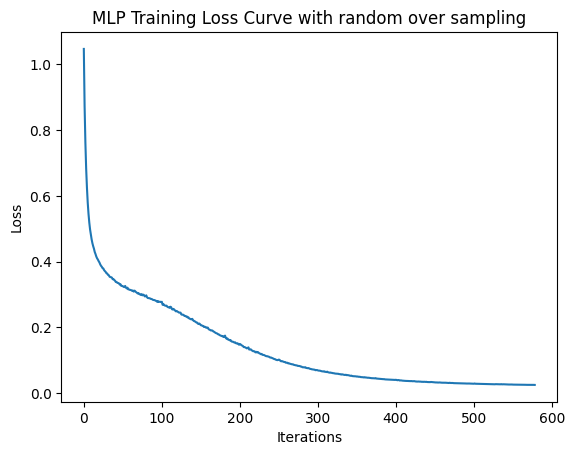

In [31]:
plt.plot(best_random_mlp_.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve with random over sampling")
plt.show()

#### Confusion matrix

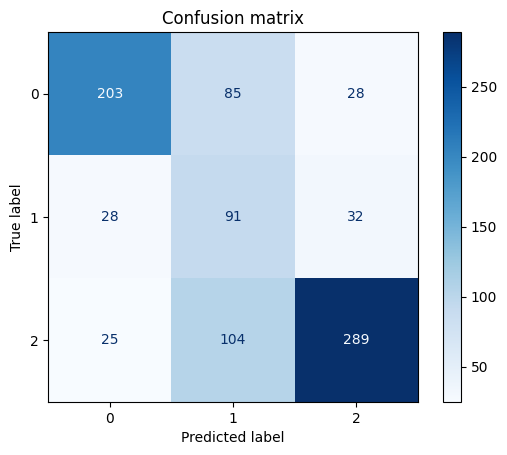

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_random_mlp_.predict(X_test_treated)  # Replace with your test data
cm = confusion_matrix(Y_test_cleaned, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

#### Learning curve

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(best_random_mlp_, X_smote_een, Y_smote_een, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation Score")
plt.xlabel("Training Samples")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

## Use the cells below this one to use create other models Jade and Wangui

To use the preprocessed data please create a copy of the test and train splits via ```df.copy()```, they are configured as such:

- Y_test_cleaned --> Y values(results) of the Test split
- X_test_cleaned --> X values of the Test split
- Y_train_cleaned --> Y values of the train split
- X_train_cleaned --> X values of the train split

**If you want to also use the oversampled datasets, these are the names of the arrays for you to copy, use them in the place of the X_train_cleaned or Y_train_cleaned:**
- Borderline SMOTE: X_borderline_SMOTE, Y_borderline_SMOTE
- Random over sampler: X_random_over_sampler, Y_random_over_sampler
- SMOTE EEN: X_smote_een, Y_smote_een
- SMOTE NC: X_smote_smnc, Y_smote_smnc